# Assignment 3

In [1]:
!pip install kaggle

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import files
from keras.preprocessing import image

In [3]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list


ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
atharvasoundankar/spotify-global-streaming-data-2024             🎧 Spotify Global Streaming Data (2024)                   14109  2025-04-07 06:26:31.707000           2060         35  1.0              
adilshamim8/student-depression-dataset                           Student Depression Dataset                              467020  2025-03-13 03:12:30.423000          13208        194  1.0              
atharvasoundankar/chocolate-sales                                Chocolate Sales Data 📊🍫                                  14473  2025-03-19 03:51:40.270000          21964        357  1.0          

In [5]:
!kaggle datasets download -d iamsouravbanerjee/animal-image-dataset-90-different-animals

Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals
License(s): other


In [6]:
import zipfile
with zipfile.ZipFile('animal-image-dataset-90-different-animals.zip', 'r') as zip_ref:
    zip_ref.extractall('animal_dataset')


Found 4320 images belonging to 90 classes.
Found 1080 images belonging to 90 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    81,920,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,042,202 (312.97 MB)

 Trainable params: 82,041,306 (312.96 MB)

 Non-trainable params: 896 (3.50 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 112s 719ms/step - accuracy: 0.0169 - loss: 5.6347 - val_accuracy: 0.0120 - val_loss: 8.9527 - learning_rate: 0.0010
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 123s 661ms/step - accuracy: 0.0231 - loss: 4.9904 - val_accuracy: 0.0167 - val_loss: 4.6191 - learning_rate: 0.0010
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 141s 659ms/step - accuracy: 0.0314 - loss: 4.6301 - val_accuracy: 0.0222 - val_loss: 4.5017 - learning_rate: 0.0010
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 89s 661ms/step - accuracy: 0.0349 - loss: 4.5181 - val_accuracy: 0.0407 - val_loss: 4.3457 - learning_rate: 0.0010
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 89s 662ms/step - accuracy: 0.0472 - loss: 4.3816 - val_accuracy: 0.0435 - val_loss: 4.2221 - learning_rate: 0.0010


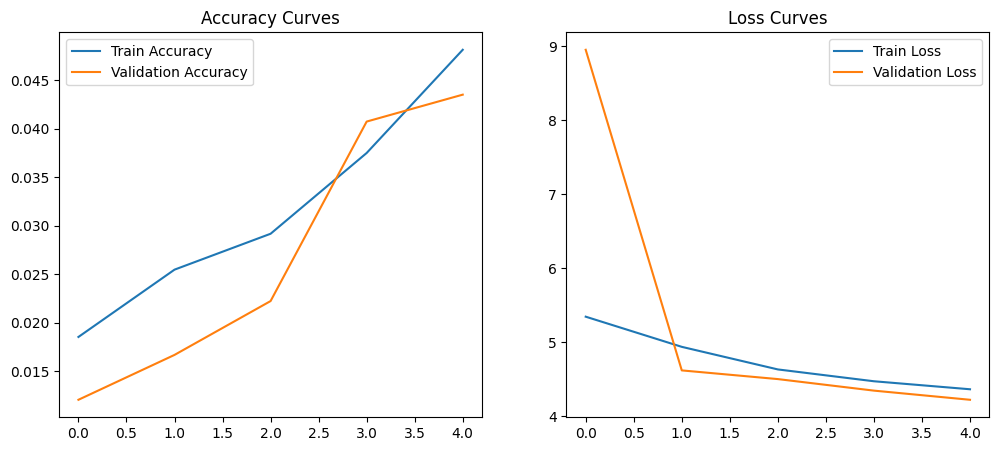

34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 518ms/step - accuracy: 0.0478 - loss: 4.2721

Final Validation Accuracy: 4.91%
Final Validation Loss: 4.2359


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest',
    validation_split=0.2
)

# Increased image size for better feature extraction
IMG_SIZE = (200, 200)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    '/content/animal_dataset/animals/animals',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/content/animal_dataset/animals/animals',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Improved CNN Architecture
model = Sequential()

# Input layer
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=IMG_SIZE + (3,)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))

# Additional Conv-Pool block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.4))

# Flatten layer
model.add(Flatten())

# Hidden layers with better regularization
model.add(Dense(256, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
model.add(Dropout(0.4))

# Output layer
model.add(Dense(90, activation='softmax'))

# Optimized learning rate and compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Enhanced Training with Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)

# Model Evaluation
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Final evaluation
test_loss, test_acc = model.evaluate(validation_generator)
print(f"\nFinal Validation Accuracy: {test_acc:.2%}")
print(f"Final Validation Loss: {test_loss:.4f}")

# Prediction function
def predict_animal(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)/255.
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    predicted_class = train_generator.class_indices.inverse()[np.argmax(predictions)]

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    return predicted_class
